- do any despeckling, do it before converting to dB
- for hackathon, run in the unstable sandbox, as the packages there are the up to date ones that will work with the SAR stuff

In [100]:
%pip uninstall odc-stac -y
%pip install odc-stac -q
%pip uninstall pystac-client -y
%pip install pystac-client -q
%pip install -U pystac-client -q
%pip uninstall dea-tools -y
%pip install dea-tools==0.4.4 -q
%pip install scikit-image -q


Found existing installation: odc-stac 0.4.0
Uninstalling odc-stac-0.4.0:
  Successfully uninstalled odc-stac-0.4.0
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Found existing installation: pystac-client 0.9.0
Uninstalling pystac-client-0.9.0:
  Successfully uninstalled pystac-client-0.9.0
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Found existing installation: dea-tools 0.4.4
Uninstalling dea-tools-0.4.4:
  Successfully uninstalled dea-tools-0.4.4
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Land cover classifier using SAR

## Description

1. Load and pre-process Sentinel-1 SAR data
2. Apply a PCA to the processed SAR data
3. Load DEA Land Cover 2.0 and collect training data (alternatively, load DEA Mangroves)
4. Train Random Forest Classifier

---

### Load packages

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import odc.geo.xr
import datacube
import gc

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedShuffleSplit,
    RandomizedSearchCV,
    GridSearchCV,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    average_precision_score,
)
from scipy.stats import randint
from scipy.ndimage import uniform_filter
from joblib import dump
from matplotlib.colors import ListedColormap
from odc.geo import BoundingBox
from odc.geo.geom import Geometry

from dea_tools.dask import create_local_dask_cluster

# for loading landsat

from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb
from dea_tools.classification import sklearn_flatten, sklearn_unflatten
from dea_tools.validation import xr_random_sampling
from dea_tools.landcover import lc_colourmap, get_colour_scheme, make_colourbar

import warnings

warnings.filterwarnings("ignore")


In [ ]:
client = create_local_dask_cluster(return_client=True)


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/39003/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/39003/status,Workers: 1
Total threads: 62,Total memory: 456.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39505,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/39003/status,Total threads: 62
Started: Just now,Total memory: 456.00 GiB
Comm: tcp://127.0.0.1:44585,Total threads: 62
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/32849/status,Memory: 456.00 GiB
Nanny: tcp://127.0.0.1:44319,


2025-09-15 01:34:29,205 - distributed.scheduler - WARNING - Detected different `run_spec` for key 'dataset-b3b66301bc005e08ad0ee970c2199aad' between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x7fcdb98168c0>, (Dataset <id=b3b66301-bc00-5e08-ad0e-e970c2199aad product=ga_s1_nrb_iw_vv_vh_0 location=https://deant-data-public-dev.s3.ap-southeast-2.amazonaws.com/experimental/for_zhengshu/ga_s1_nrb_iw_vv_vh_0/t002_003313_iw2/2024/12/23/ga_s1a_nrb_0-1-0_T002-003313-IW2_20241223T203304Z_stac-item.json>,), {})
new run_spec: (<function execute_task at 0x7fcdb98168c0>, (Dataset <id=b3b66301-bc00-5e08-ad0e-e970c2

In [ ]:
# becaause I'm working in the devbox with a sandbox kernel I can't "find" the src folder so I've copied the speckle filter code here


# Adapted from https://stackoverflow.com/questions/39785970/speckle-lee-filter-in-python
def lee_filter(img, size):
    """
    Applies the Lee filter to reduce speckle noise in an image.

    Parameters:
    img (ndarray): Input image to be filtered.
    size (int): Size of the uniform filter window.

    Returns:
    ndarray: The filtered image.
    """
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img**2, size)
    img_variance = img_sqr_mean - img_mean**2

    overall_variance = np.var(img)

    img_weights = img_variance / (img_variance + overall_variance)
    img_output = img_mean + img_weights * (img - img_mean)
    return img_output


# Define a function to apply the Lee filter to a DataArray
def apply_lee_filter(data_array, size=7):
    """
    Applies the Lee filter to the provided DataArray.

    Parameters:
    data_array (xarray.DataArray): The data array to be filtered.
    size (int): Size of the uniform filter window. Default is 7.

    Returns:
    xarray.DataArray: The filtered data array.
    """
    data_array_filled = data_array.fillna(0)
    filtered_data = xr.apply_ufunc(
        lee_filter,
        data_array_filled,
        kwargs={"size": size},
        input_core_dims=[["y", "x"]],
        output_core_dims=[["y", "x"]],
        dask_gufunc_kwargs={"allow_rechunk": True},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[data_array.dtype],
    )
    return filtered_data


### Environment setup

In [ ]:
dc = datacube.Datacube(env="dev", app="S1_Backscatter_Demo")


### Set search parameters

In [ ]:
product_to_load = "ga_s1_nrb_iw_vv_vh_0"
measurements_to_load = ["VV_gamma0", "VH_gamma0", "mask"]
output_crs = "EPSG:3577"
output_res = 20

# region code for mini tiles
# region_codes = ["x148y166"]
region_codes = ["x149y166"]

year = "2024"
start_date = f"{year}-01-01"
end_date = f"{year}-12-30"


In [ ]:
# open tiles and select

gdf = gpd.read_file(
    "~/gdata1/projects/fc-sub-annual/data/testing_minitile_suite.geojson"
)

gdf = gdf[gdf["region_code"].isin(region_codes)]
geom = Geometry(geom=gdf.iloc[0].geometry, crs=gdf.crs)

# for stac:
minx, miny, maxx, maxy = gdf.total_bounds
bbox = [minx, miny, maxx, maxy]
geom_bbox = BoundingBox(left=minx, bottom=miny, right=maxx, top=maxy, crs="EPSG:4326")


### Load Sentinel-1, Sentinel-2 and Land Cover data from the datacube

 * Sentinel-1 SAR data
 * Sentinel-2 multispectral data (for making RGB images of the AOI, maybe also to use as input to model)
 * Land Cover will be used to collect training data for the model

In [ ]:
# using datacube to load multispec data so I can use load_ard for masking
s2 = load_ard(
    dc=dc,
    products=["ga_s2am_ard_3", "ga_s2bm_ard_3"],
    measurements=["nbart_red", "nbart_green", "nbart_blue", "nbart_nir_1"],
    cloud_mask="s2cloudless",
    mask_pixel_quality=True,
    mask_contiguity=True,
    skip_broken_datasets=True,
    time=(start_date, end_date),
    resolution=(-20, 20),
    geopolygon=geom_bbox.boundary(),
    output_crs="EPSG:3577",
    dask_chunks={},
)


Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
Applying s2cloudless pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Returning 63 time steps as a dask array


In [ ]:
# load SAR with datacube
s1 = dc.load(
    product=product_to_load,
    measurements=measurements_to_load,
    time=(start_date, end_date),
    resolution=(-20, 20),
    output_crs="EPSG:3577",
    geopolygon=geom_bbox.boundary(),
    group_by="solar_day",
    dask_chunks={},
)


In [ ]:
s1


<xarray.Dataset> Size: 461MB
Dimensions:      (time: 18, y: 1686, x: 1686)
Coordinates:
  * time         (time) datetime64[ns] 144B 2024-06-02T20:33:10.304234 ... 20...
  * y            (y) float64 13kB -1.567e+06 -1.567e+06 ... -1.601e+06
  * x            (x) float64 13kB 3.512e+05 3.512e+05 ... 3.849e+05 3.849e+05
    spatial_ref  int32 4B 3577
Data variables:
    VV_gamma0    (time, y, x) float32 205MB dask.array<chunksize=(1, 1686, 1686), meta=np.ndarray>
    VH_gamma0    (time, y, x) float32 205MB dask.array<chunksize=(1, 1686, 1686), meta=np.ndarray>
    mask         (time, y, x) uint8 51MB dask.array<chunksize=(1, 1686, 1686), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [ ]:
lc = dc.load(
    product="ga_ls_landcover_class_cyear_3",
    measurements=["level3"],
    resolution=(-30, 30),  # make this a multiple of 20
    output_crs="EPSG:3577",
    group_by="solar_day",
    time=(year),
    geopolygon=geom_bbox.boundary(),
    dask_chunks={},
)


### Speckle filtering (optional) and compositing a monthly mean

based on some discussion in Teams, mean is better for SAR than median, and it should be done before converting to db. This may also mean I don't need to do a speckle filter.
Will apply the mask first, and then compare speckly filter and monthly means.

In [ ]:
s1["VV_gamma0_masked"] = xr.where(s1.mask == 0, s1["VV_gamma0"], np.nan)
s1["VH_gamma0_masked"] = xr.where(s1.mask == 0, s1["VH_gamma0"], np.nan)


#### Masking

The GA Sentinel-1 backscatter product comes with a mask that indicates invalid pixels, along with pixels impacted by layover and shadow. 

The masks have the following values:
| Value | Property |
| --- | ----------- |
| 0 | Valid | 
| 1 | Shadow |
| 2 | Layover |
| 3 | Shadow and layover |
| 255 / NaN | Invalid |

The following code displays the masks and shows how to apply them.

In [ ]:
s1["VV_gamma0_masked_filtered"] = apply_lee_filter(s1["VV_gamma0_masked"], size=5)
s1["VH_gamma0_masked_filtered"] = apply_lee_filter(s1["VH_gamma0_masked"], size=5)


## Ratio of VV to VH band

We can calculate the ratio of the vertical polarisation band to the horizontal polarisation band.

This is something done in the DEAfrica notebook [Sentinel-1 Monthly Mosaic](https://docs.digitalearthafrica.org/en/latest/sandbox/notebooks/Datasets/Sentinel_1_Mosaic.html)

Note that because we want to preserve both the monthly means with and without the speckle filtering applied, we are applying the following operations to both arrays.

In [ ]:
# make ratio of VV to VH band
s1["VH_over_VV_gamma0_masked"] = s1["VH_gamma0_masked"] / s1["VV_gamma0_masked"]
s1["VH_over_VV_gamma0_masked_filtered"] = (
    s1["VH_gamma0_masked_filtered"] / s1["VV_gamma0_masked_filtered"]
)


In [ ]:
# converting to dB, simplify data array name for future steps

s1["VV"] = 10 * np.log10(s1["VV_gamma0_masked"])
s1["VH"] = 10 * np.log10(s1["VH_gamma0_masked"])
s1["VH_over_VV"] = 10 * np.log10(s1["VH_over_VV_gamma0_masked"])

s1["VV_filtered"] = 10 * np.log10(s1["VV_gamma0_masked_filtered"])
s1["VH_filtered"] = 10 * np.log10(s1["VH_gamma0_masked_filtered"])
s1["VH_over_VV_filtered"] = 10 * np.log10(s1["VH_over_VV_gamma0_masked_filtered"])


In [ ]:
print(
    f"vh_over_vv, dB scale range: {s1['VH_over_VV_filtered'].min().compute().item()}, {s1['VH_over_VV_filtered'].max().compute().item()} \n"
)
print(
    f"vv, dB scale range: {s1['VV_filtered'].min().compute().item()}, {s1['VV_filtered'].max().compute().item()} \n"
)
print(
    f"vh, dB scale range: {s1['VH_filtered'].min().compute().item()}, {s1['VH_filtered'].max().compute().item()} \n"
)


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


vh_over_vv, dB scale range: -36.32305908203125, 5.806613445281982 

vv, dB scale range: -30.253684997558594, 9.489583969116211 

vh, dB scale range: -35.78264617919922, -2.320481300354004 



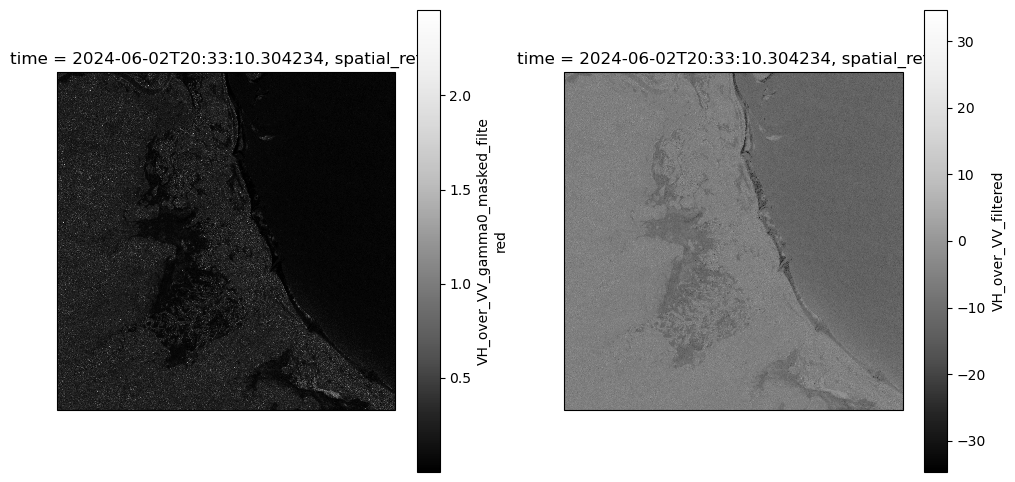

In [ ]:
# compare before and after of dB for vv/vh band

fig, ax = plt.subplots(
    1, 2, figsize=(12, 6), subplot_kw={"projection": ccrs.epsg(3577)}
)
s1["VH_over_VV_gamma0_masked_filtered"].isel(time=0).plot(
    ax=ax[0],
    cmap="Greys_r",
)

s1["VH_over_VV_filtered"].isel(time=0).plot(
    ax=ax[1],
    cmap="Greys_r",
)


#### Monthly mean of SAR, monthly median of Sentinel-2

In [ ]:
# group by month
s1_grouped = s1.groupby("time.month")

# make template for monthly xarray dataset
s1_month_template = s1_grouped.mean(dim="time", keep_attrs=True)

# make empty xarray dataset with same structure as template
s1_month = s1_month_template.copy(deep=True)
for var in s1_month.data_vars:
    s1_month[var].values[:] = np.nan


s1_month_filtered = s1_month.copy(deep=True)


In [ ]:
s1_month["mean_vv"] = s1["VV"].groupby("time.month").mean(dim="time", keep_attrs=True)
s1_month["mean_vh"] = s1["VH"].groupby("time.month").mean(dim="time", keep_attrs=True)
s1_month["mean_vh_over_vv"] = (
    s1["VH_over_VV"].groupby("time.month").mean(dim="time", keep_attrs=True)
)

# repeat for the lee filtered variables
s1_month_filtered["mean_vv"] = (
    s1["VV_filtered"].groupby("time.month").mean(dim="time", keep_attrs=True)
)
s1_month_filtered["mean_vh"] = (
    s1["VH_filtered"].groupby("time.month").mean(dim="time", keep_attrs=True)
)
s1_month_filtered["mean_vh_over_vv"] = (
    s1["VH_over_VV_filtered"].groupby("time.month").mean(dim="time", keep_attrs=True)
)


In [ ]:
s1_month["min_vv"] = s1["VV"].groupby("time.month").min(dim="time", keep_attrs=True)
s1_month["min_vh"] = s1["VH"].groupby("time.month").min(dim="time", keep_attrs=True)
s1_month["min_vh_over_vv"] = (
    s1["VH_over_VV"].groupby("time.month").min(dim="time", keep_attrs=True)
)

s1_month["max_vv"] = s1["VV"].groupby("time.month").max(dim="time", keep_attrs=True)
s1_month["max_vh"] = s1["VH"].groupby("time.month").max(dim="time", keep_attrs=True)
s1_month["max_vh_over_vv"] = (
    s1["VH_over_VV"].groupby("time.month").max(dim="time", keep_attrs=True)
)

s1_month["std_vv"] = s1["VV"].groupby("time.month").std(dim="time", keep_attrs=True)
s1_month["std_vh"] = s1["VH"].groupby("time.month").std(dim="time", keep_attrs=True)
s1_month["std_vh_over_vv"] = (
    s1["VH_over_VV"].groupby("time.month").std(dim="time", keep_attrs=True)
)

# repeat for the lee filtered variables
s1_month_filtered["min_vv"] = (
    s1["VV_filtered"].groupby("time.month").min(dim="time", keep_attrs=True)
)
s1_month_filtered["min_vh"] = (
    s1["VH_filtered"].groupby("time.month").min(dim="time", keep_attrs=True)
)
s1_month_filtered["min_vh_over_vv"] = (
    s1["VH_over_VV_filtered"].groupby("time.month").min(dim="time", keep_attrs=True)
)

s1_month_filtered["max_vv"] = (
    s1["VV_filtered"].groupby("time.month").max(dim="time", keep_attrs=True)
)
s1_month_filtered["max_vh"] = (
    s1["VH_filtered"].groupby("time.month").max(dim="time", keep_attrs=True)
)
s1_month_filtered["max_vh_over_vv"] = (
    s1["VH_over_VV_filtered"].groupby("time.month").max(dim="time", keep_attrs=True)
)

s1_month_filtered["std_vv"] = (
    s1["VV_filtered"].groupby("time.month").std(dim="time", keep_attrs=True)
)
s1_month_filtered["std_vh"] = (
    s1["VH_filtered"].groupby("time.month").std(dim="time", keep_attrs=True)
)
s1_month_filtered["std_vh_over_vv"] = (
    s1["VH_over_VV_filtered"].groupby("time.month").std(dim="time", keep_attrs=True)
)


In [ ]:
s1_month.compute()
s1_month_filtered.compute()


<xarray.Dataset> Size: 2GB
Dimensions:                            (month: 7, y: 1686, x: 1686)
Coordinates:
  * y                                  (y) float64 13kB -1.567e+06 ... -1.601...
  * x                                  (x) float64 13kB 3.512e+05 ... 3.849e+05
    spatial_ref                        int32 4B 3577
  * month                              (month) int64 56B 6 7 8 9 10 11 12
Data variables: (12/27)
    VV_gamma0                          (month, y, x) float32 80MB 0.00252 ......
    VH_gamma0                          (month, y, x) float32 80MB 0.001474 .....
    mask                               (month, y, x) float64 159MB 0.0 ... 0.0
    VV_gamma0_masked                   (month, y, x) float32 80MB 0.00252 ......
    VH_gamma0_masked                   (month, y, x) float32 80MB 0.001474 .....
    VV_gamma0_masked_filtered          (month, y, x) float32 80MB 0.00403 ......
    ...                                 ...
    max_vv                             (month, y, x) float32 80MB -22.78 ... ...
    max_vh                             (month, y, x) float32 80MB -26.91 ... ...
    max_vh_over_vv                     (month, y, x) float32 80MB -1.142 ... ...
    std_vv                             (month, y, x) float32 80MB 1.701 ... 2...
    std_vh                             (month, y, x) float32 80MB 0.3895 ... ...
    std_vh_over_vv                     (month, y, x) float32 80MB 1.56 ... 1.274
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [ ]:
s2_month = s2.groupby("time.month").median("time", keep_attrs=True)


In [ ]:
# delete original s1 to save memory
del s1
del s1_grouped
del s1_month_template
del s2
gc.collect()


811

#### Compare the monthly Sentinel-2 mean, with and without speckle filtering

A quick visual comparison of the mean monthly composites from Sentinel-1, with and without Lee filtering applied.

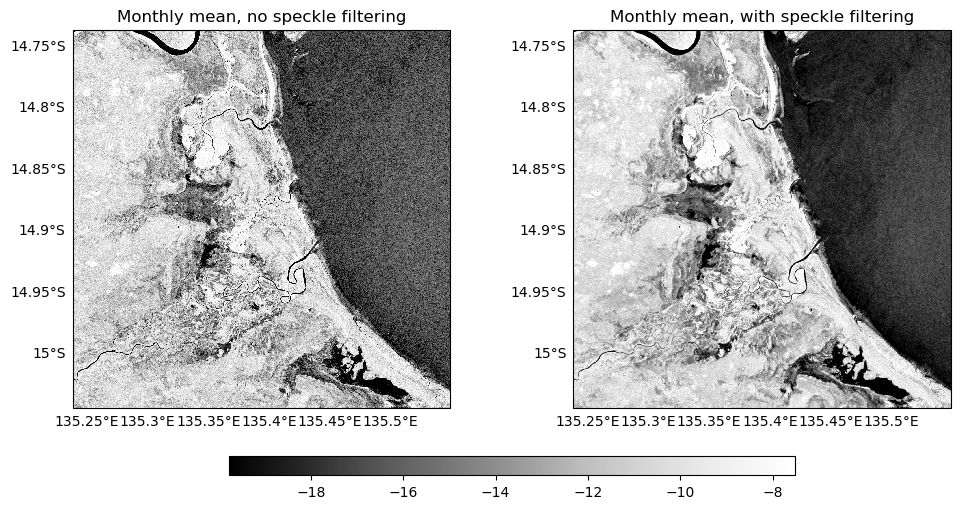

In [ ]:
# before and after speckle filtering

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
    layout="constrained",
    subplot_kw={"projection": ccrs.epsg(3577)},
)

s1_timestep = s1_month.isel(month=0)
s1_timestep_filtered = s1_month_filtered.isel(month=0)

vmin = float(s1_timestep["mean_vv"].quantile(0.02))
vmax = float(s1_timestep["mean_vv"].quantile(0.98))

vmin_fil = float(s1_timestep_filtered["mean_vv"].quantile(0.02))
vmax_fil = float(s1_timestep_filtered["mean_vv"].quantile(0.98))

im0 = s1_timestep["mean_vv"].plot(
    ax=axes[0],
    cmap="Greys_r",
    robust=True,
    transform=ccrs.epsg(3577),
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title("Monthly mean, no speckle filtering")
gl0 = axes[0].gridlines(draw_labels=True)
gl0.xlines = False
gl0.ylines = False
gl0.right_labels = False
gl0.top_labels = False

im1 = s1_timestep_filtered["mean_vv"].plot(
    ax=axes[1],
    cmap="Greys_r",
    robust=True,
    transform=ccrs.epsg(3577),
    add_colorbar=False,
    vmin=vmin_fil,
    vmax=vmax_fil,
)
axes[1].set_title("Monthly mean, with speckle filtering")
gl1 = axes[1].gridlines(draw_labels=True)
gl1.xlines = False
gl1.ylines = False
gl1.right_labels = False
gl1.top_labels = False


cbar = fig.colorbar(
    im1, ax=axes, orientation="horizontal", fraction=0.05, pad=0.07, aspect=30
)
plt.show()


The assignment of vertical and horizontal bands as red and green, respectively, and the ratio as the blue band, is a common way to visualise SAR data.

In [ ]:
# histogram of pixels for each band


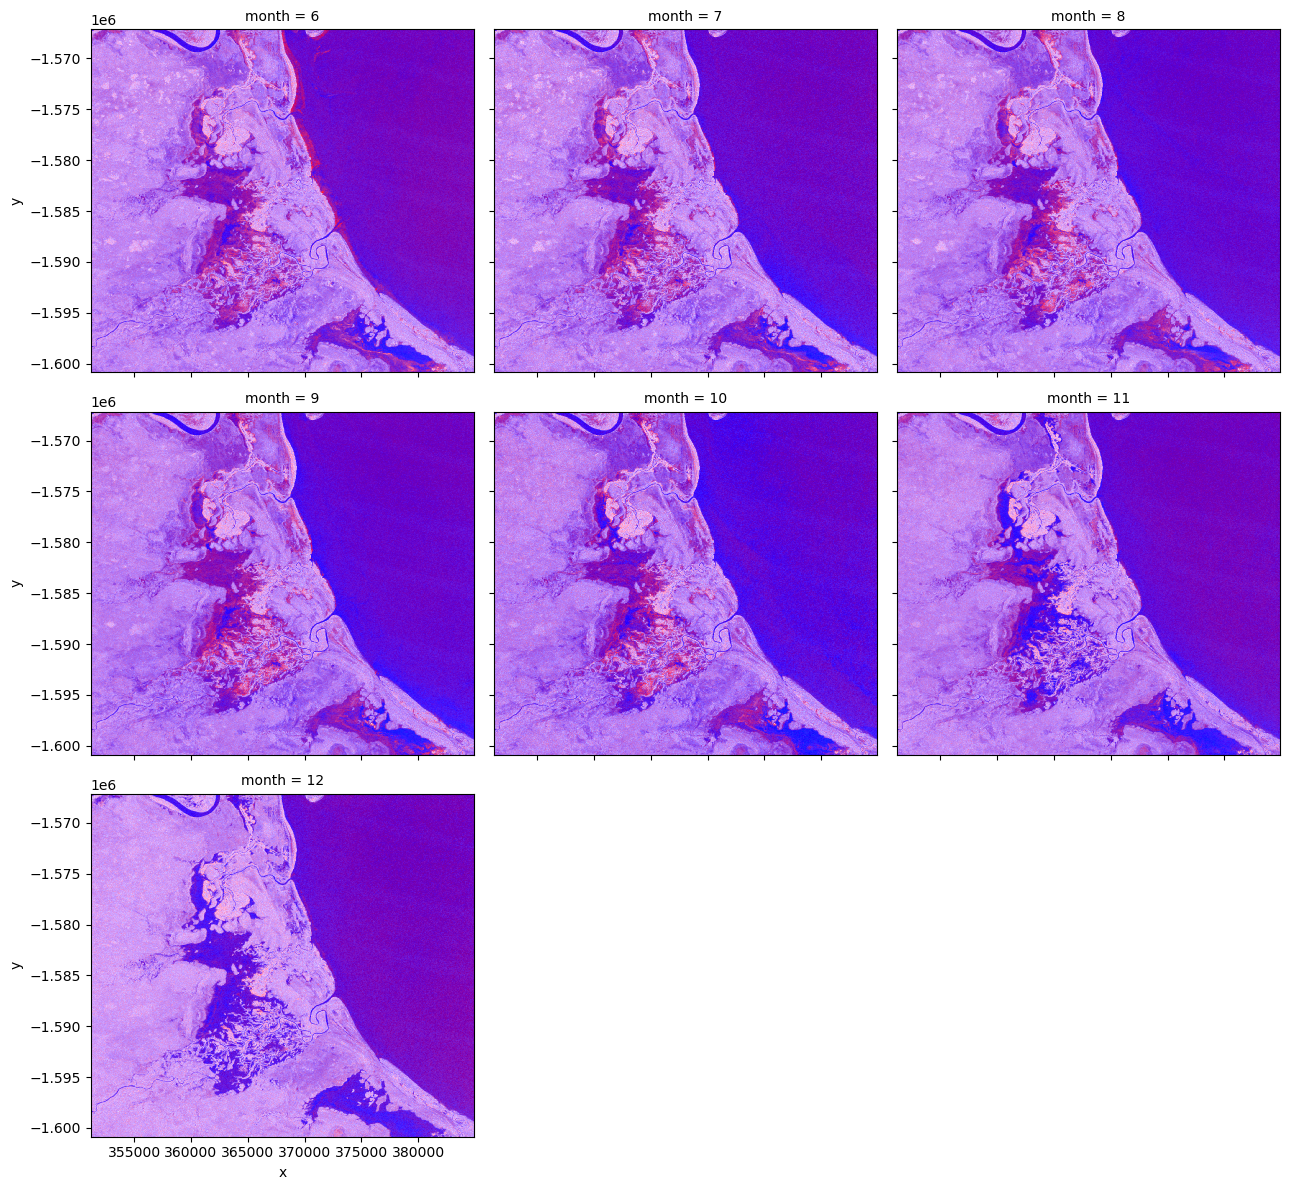

In [ ]:
rgb(
    s1_month_filtered,
    bands=["mean_vv", "mean_vh", "mean_vh_over_vv"],
    col="month",
    col_wrap=3,
    size=4,
)


## prepare data for PCA and do PCA


In [ ]:
# s2_month.compute()


In [ ]:
if "month" in s1_month.dims:
    s1_month = s1_month.rename({"month": "time"})
if "month" in s1_month_filtered.dims:
    s1_month_filtered = s1_month_filtered.rename({"month": "time"})
if "month" in s2_month.dims:
    s2_month = s2_month.rename({"month": "time"})


In [ ]:
x_s1 = sklearn_flatten(s1_month_filtered)
pca_s1 = PCA(n_components=3)


In [ ]:
x_s1_clean = np.where(np.isfinite(x_s1), x_s1, np.nan)
x_s1_clean = np.nan_to_num(x_s1_clean)

pca_s1.fit(x_s1_clean)
print("Relative variance in principal components:", pca_s1.explained_variance_ratio_)


Relative variance in principal components: [9.99245522e-01 6.46372461e-04 6.64059613e-05]


In [ ]:
predict_s1 = pca_s1.transform(x_s1_clean)


In [ ]:
out_s1 = sklearn_unflatten(predict_s1, s1_month_filtered)
out_s1 = out_s1.to_dataset(dim=out_s1.dims[0]).transpose("time", "y", "x")
out_s1 = out_s1.rename({0: "pc1", 1: "pc2", 2: "pc3"})


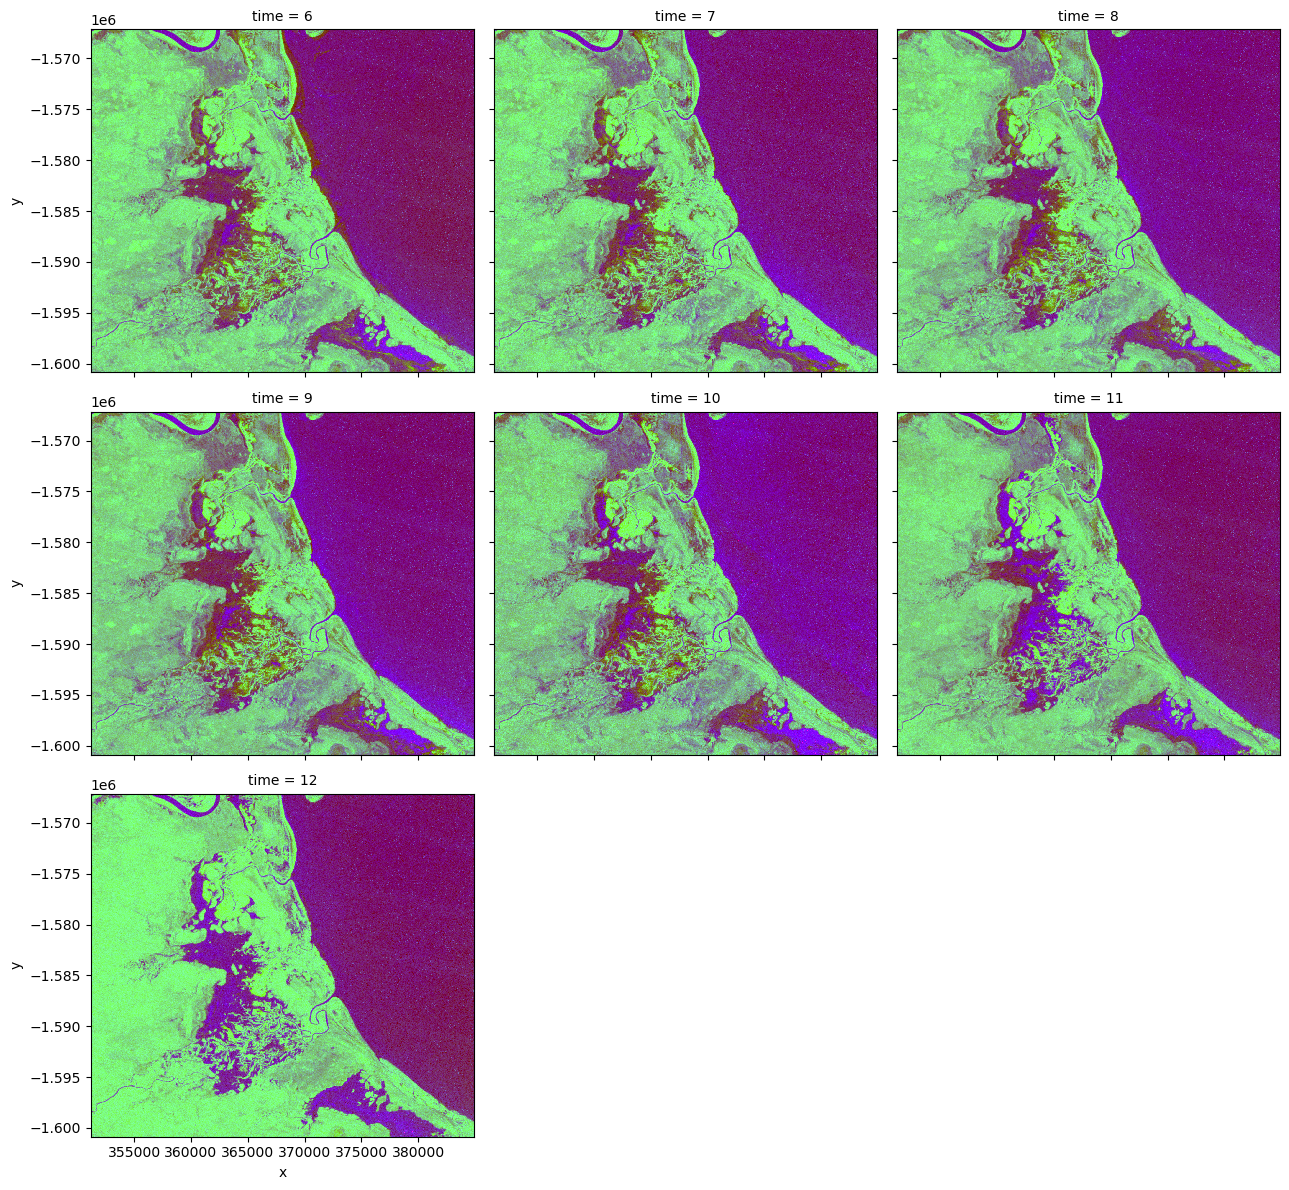

In [ ]:
rgb(out_s1, bands=["pc1", "pc2", "pc3"], col="time", col_wrap=3, size=4)


## Random sampling to build training dataset from land cover 2.0

In [ ]:
lc = lc["level3"].squeeze()
lc = lc.where(lc != 255)  # Mask out no data values


In [ ]:
# Equal stratified random samples
train_points = xr_random_sampling(lc, sampling="equal_stratified_random", n=1000)


Class 111: sampling 200 points
Class 112: sampling 200 points
Class 124: sampling 200 points
Class 216: sampling 200 points
Class 220: sampling 200 points


In [ ]:
# fig, ax = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# colour_scheme = get_colour_scheme("level3")
# cmap, norm = lc_colourmap(colour_scheme)

# # Trim no-data off the colormap
# cmap2 = ListedColormap(cmap.colors[:-1])

# s2_month[["nbart_red", "nbart_green", "nbart_blue"]].isel(
#     time=0
# ).to_array().plot.imshow(robust=True, ax=ax[0], add_labels=False)
# train_points.plot(ax=ax[0], column="class", cmap=cmap2, legend=True, categorical=True)

# ax[0].set_title("RGB Sentinel-2 Median, month 0")
# ax[0].axes.get_xaxis().set_ticks([])
# ax[0].axes.get_yaxis().set_ticks([])

# s1_month_filtered[["mean_vv", "mean_vh", "mean_vh_over_vv"]].isel(
#     time=0
# ).to_array().plot.imshow(robust=True, ax=ax[1], add_labels=False)
# ax[1].set_title("RGB Sentinel-1 Median, month 0 (VV, VH, VH over VV)")
# ax[1].axes.get_xaxis().set_ticks([])
# ax[1].axes.get_yaxis().set_ticks([])


# im = lc.plot(cmap=cmap, norm=norm, ax=ax[2], add_labels=False, add_colorbar=False)
# make_colourbar(fig, ax[2], measurement="level3", labelsize=7, horizontal=False)

# ax[2].set_title("DEA Land Cover")
# ax[2].axes.get_xaxis().set_ticks([])
# ax[2].axes.get_yaxis().set_ticks([])


## Combine original bands, PCA and GLCM to use for random forrest

In [ ]:
train_points


,class,geometry
0,111,POINT (364065.000 -1580835.000)
1,111,POINT (367875.000 -1569135.000)
2,111,POINT (366405.000 -1593315.000)
3,111,POINT (357975.000 -1578345.000)
4,111,POINT (364035.000 -1580805.000)
...,...,...
995,220,POINT (375225.000 -1588005.000)
996,220,POINT (363915.000 -1588215.000)
997,220,POINT (377235.000 -1597005.000)
998,220,POINT (374085.000 -1580205.000)


In [ ]:
# s1_month_filtered.compute()
# out_s1.compute()


In [ ]:
combined_inputs = xr.merge([s1_month_filtered, out_s1])
combined_inputs = combined_inputs.compute()


In [ ]:
cols = ["class"] + [
    f"{stat}_{band}_{month}"
    for stat in ["mean", "max", "min", "std"]
    for band in ["vv", "vh", "vh_over_vv"]
    for month in range(6, 13)
]

cols_pca = [f"{pc}_{month}" for pc in ["pc1", "pc2", "pc3"] for month in range(6, 13)]

cols = cols + cols_pca

train_df = pd.DataFrame(columns=cols, index=range(len(train_points)))


In [ ]:
for i, (c, g) in enumerate(zip(train_points["class"], train_points.geometry)):
    print(i, end="\r")
    ds_point = combined_inputs.sel(x=g.x, y=g.y, method="nearest")

    # assign response variable (row i, first column, i.e. column index 0)
    train_df.loc[i, "class"] = c

    for col in train_df.columns[1:]:
        var = "_".join(col.split("_")[:-1])
        month = int(col.split("_")[-1])

        train_df.loc[i, col] = ds_point.sel(time=month)[var].data


In [ ]:
class_map = {111: 0, 112: 1, 124: 2, 215: 3, 216: 4, 220: 5}
inv_class_map = {v: k for k, v in class_map.items()}


In [ ]:
train_df["class_int"] = train_df["class"].map(class_map)


In [ ]:
train_df


,class,mean_vv_6,mean_vv_7,mean_vv_8,mean_vv_9,mean_vv_10,mean_vv_11,mean_vv_12,mean_vh_6,mean_vh_7,...,pc2_11,pc2_12,pc3_6,pc3_7,pc3_8,pc3_9,pc3_10,pc3_11,pc3_12,class_int
0,111,-15.145748,-14.654762,-14.960277,-14.873717,-16.031513,-16.392029,-13.616463,-25.201284,-24.29329,...,-10.598622908094931,0.8720886496064182,-5.944044038593491,-4.184732331589842,-7.90111571616438,-7.334348245882692,-7.738151013255816,0.7438709454498464,-1.5711765607047687,0
1,111,-9.76401,-10.4049015,-11.178383,-9.803777,-10.45995,-11.311848,-9.918509,-14.302364,-15.479795,...,13.563107259183028,18.43513202990688,1.9808766601862835,-0.14993328061538858,2.0787116296360595,-4.795852451163032,-11.286539214192924,0.9215052334744009,1.0110971258880244,0
2,111,-11.721112,-11.873384,-12.046879,-11.082344,-10.7542,-11.781068,-10.7859745,-18.272135,-19.602165,...,8.722358476951712,15.549461750183895,1.6892539010976173,-2.6426370958253007,0.5582846811186881,-3.034483860443254,-2.6294507553313218,-1.66118328425434,0.3782990295403734,0
3,111,-12.866904,-12.706771,-13.532765,-12.708572,-13.597651,-12.911151,-10.776779,-17.653996,-19.294317,...,11.830869950479226,12.46472489280415,6.720156274123877,0.3603971179461616,-0.6230444380062754,-0.45833544431404416,-0.9559281308963983,8.205151131315112,-1.3328791463812055,0
4,111,-14.617524,-14.311073,-14.645847,-15.1000395,-15.969217,-16.445696,-13.510092,-24.889006,-24.651745,...,-12.564403794826212,-1.6883940787749268,-7.587704784419804,-6.916071074065698,-5.5594706194146255,-5.069320806556904,-2.88289055057666,-3.3673760938505723,-3.0293920771934064,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,220,-18.307375,-18.854916,-19.588411,-20.438652,-19.82316,-19.65153,-17.881325,-28.37874,-28.217655,...,-19.75672049293646,-23.775000032042477,-0.5134568588844268,2.5348845976849956,5.323274232083008,8.732415021425263,1.0590869690788511,2.661535547410595,-8.846300721009465,5
996,220,-15.247955,-15.166916,-13.784656,-19.989279,-18.098751,-23.19799,-20.13233,-26.213129,-25.41006,...,-19.288859053975308,-15.115109919945944,-9.075845317621377,-8.349050642812374,-11.956788547768104,0.9896423119063729,-4.9767866595402115,11.651612248080843,5.702606859563071,5
997,220,-22.369635,-22.434898,-22.553034,-25.057623,-25.98801,-25.473032,-17.933962,-26.565634,-26.9294,...,-22.41233606434657,-14.683108708764571,18.20255543772123,12.26063206153393,12.04446391349739,21.377791513083302,20.081583406642125,31.28930346373826,-2.572472293015099,5
998,220,-17.730333,-18.116127,-19.092447,-19.723288,-21.865505,-18.94516,-17.903824,-28.431345,-27.838856,...,-19.85017840754211,-20.794957176554796,-4.281109356303478,-0.800129394863236,1.7235767091754295,2.9715292927336883,8.310185629409865,-3.509013961820678,-9.181196464855617,5


In [ ]:
train_df.to_csv("~/gdata1/projects/jenna_temp/lc_samples.csv", index=False)


### Split train/test

In [ ]:
def split_train_test(df, test_size=0.2):
    # apply stratified sampling
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size)
    for train_index, test_index in strat_split.split(df, df["class"]):
        train = df.loc[train_index].copy()
        test = df.loc[test_index].copy()
        return train, test


In [ ]:
train_final, test_final = split_train_test(train_df)


In [ ]:
predictors = cols[1:]


In [ ]:
# define response and explanatory vars train_final dataset
resp_train = train_final["class_int"].copy()
expl_train = train_final[predictors].copy()

# define response and explanatory for test_final
resp_test = test_final["class_int"].copy()
expl_test = test_final[predictors].copy()

print(f"train count: {len(resp_train.index)}")
print(f"test count: {len(resp_test.index)}")


train count: 800
test count: 200


### Random forest classifier

In [ ]:
rf = RandomForestClassifier(n_jobs=-1)


In [ ]:
# ranges of possible hyperparameters
hyperpar = {
    "n_estimators": randint(low=10, high=100),
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": randint(low=5, high=20),
    "min_samples_split": randint(low=2, high=20),
    "min_samples_leaf": randint(low=1, high=20),
    "max_features": randint(low=1, high=len(predictors)),
    "bootstrap": [True, False],
}


In [ ]:
expl_train


,mean_vv_6,mean_vv_7,mean_vv_8,mean_vv_9,mean_vv_10,mean_vv_11,mean_vv_12,mean_vh_6,mean_vh_7,mean_vh_8,...,pc2_10,pc2_11,pc2_12,pc3_6,pc3_7,pc3_8,pc3_9,pc3_10,pc3_11,pc3_12
827,-23.555496,-25.062748,-22.500765,-25.512222,-25.973965,-22.893349,-19.664776,-25.98623,-26.827768,-25.750694,...,-19.53542020801431,-19.23309489915794,-15.517358599741549,17.340341008060047,20.942332473405745,15.926346826439048,26.807105504144292,23.55531321897308,10.809943778711396,5.053761909761995
593,-7.5788503,-6.9181786,-7.6000085,-7.267549,-6.1771116,-9.062461,-7.0258126,-14.080127,-14.6078,-10.847664,...,26.14991437301066,21.394418119315688,21.767674607864606,-4.089398216934773,-7.378004622882544,2.4785155563502874,-0.5572561660301258,-6.155726698065179,0.41328040975228264,-7.167981325417946
394,-11.247069,-11.895932,-11.365352,-11.200508,-11.6936035,-10.61167,-9.958983,-17.45503,-17.240738,-17.36459,...,10.626348477906632,14.560834975986133,25.39504523871227,0.5598128870729036,2.0310602187269424,-0.15459072142618124,4.00812844918171,-0.20786606129291663,0.4216977859783446,7.889844747346995
441,-5.963511,-6.257033,-7.519092,-7.5162544,-5.1902204,-6.63086,-8.515484,-13.709592,-12.585331,-12.396881,...,26.847863504827814,28.944914339073694,21.740998798869,-7.110932918228505,-4.591928180064794,-0.9155061362087635,-1.3247500928725922,-9.218923342666864,-2.4983399837547196,-1.3918815821784798
828,-18.434557,-18.624542,-19.586878,-18.59949,-19.872213,-18.296564,-18.632637,-29.802238,-28.325413,-28.837423,...,-24.54472804514213,-22.511748874340974,-19.961655785811082,-3.23833491075349,-1.5246699794612852,-0.8525360933406838,-0.7719034345857656,-2.9866744864912618,-8.59067403513278,-3.7028667144702037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,-18.492895,-19.026648,-19.600378,-18.990685,-19.8236,-18.438887,-18.45277,-28.390882,-27.95362,-28.731926,...,-24.91801626646224,-19.094239466551734,-14.223370018161923,1.5383631723454043,1.7566274115415523,-2.322280334051435,2.7302153324269347,-3.7917465404484223,-0.783067373526082,5.402404769269237
926,-9.312785,-9.65818,-9.995286,-9.582527,-8.855323,-14.447507,-13.273901,-19.136673,-19.855862,-19.517733,...,12.35921239923811,-0.2262592785781763,7.201586724046074,-9.513450702301789,-11.075013312919985,-8.002081927712606,-8.420368729179621,-8.990153488980104,1.5510805570699233,5.75972441865961
847,-19.146086,-19.977264,-19.284416,-20.809256,-18.417654,-19.610466,-17.170948,-27.120728,-26.3428,-26.87976,...,-17.778421797078686,-18.632819905640524,-12.426851892774955,5.484532868446694,5.346377727531832,4.421215465513342,1.6008558406470876,-4.461924087522867,1.9960922011301654,-0.6670364100661903
212,-10.51049,-10.993605,-11.328427,-10.968823,-11.084715,-10.313973,-8.538868,-16.376043,-15.692768,-16.141127,...,13.106906352066389,13.248102747035027,20.461196017487687,-0.4273017047506418,5.287866573320074,3.632343552787066,1.084698346561564,0.5312552312953103,-1.491963976545462,-3.8479000655501383


In [ ]:
## N.B.: ideally a random state/random seed should be set
rf_rand_search = RandomizedSearchCV(
    rf,
    param_distributions=hyperpar,
    n_iter=200,
    scoring="f1_weighted",
    cv=5,
    verbose=1,
    n_jobs=-1,
)

rf_rand_search.fit(expl_train, resp_train)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fcdc83b71f0>,
                                        'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fcf788a5420>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fd0079fd540>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fd004adb9a0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fcdc83b5240>},
                   scoring='f1_weighted', verbose=1)

In [ ]:
# best model and score of best model
rf_rand_search.best_params_, rf_rand_search.best_score_


({'bootstrap': False,
  'criterion': 'log_loss',
  'max_depth': 17,
  'max_features': 9,
  'min_samples_leaf': 12,
  'min_samples_split': 15,
  'n_estimators': 13},
 0.7325255231014345)

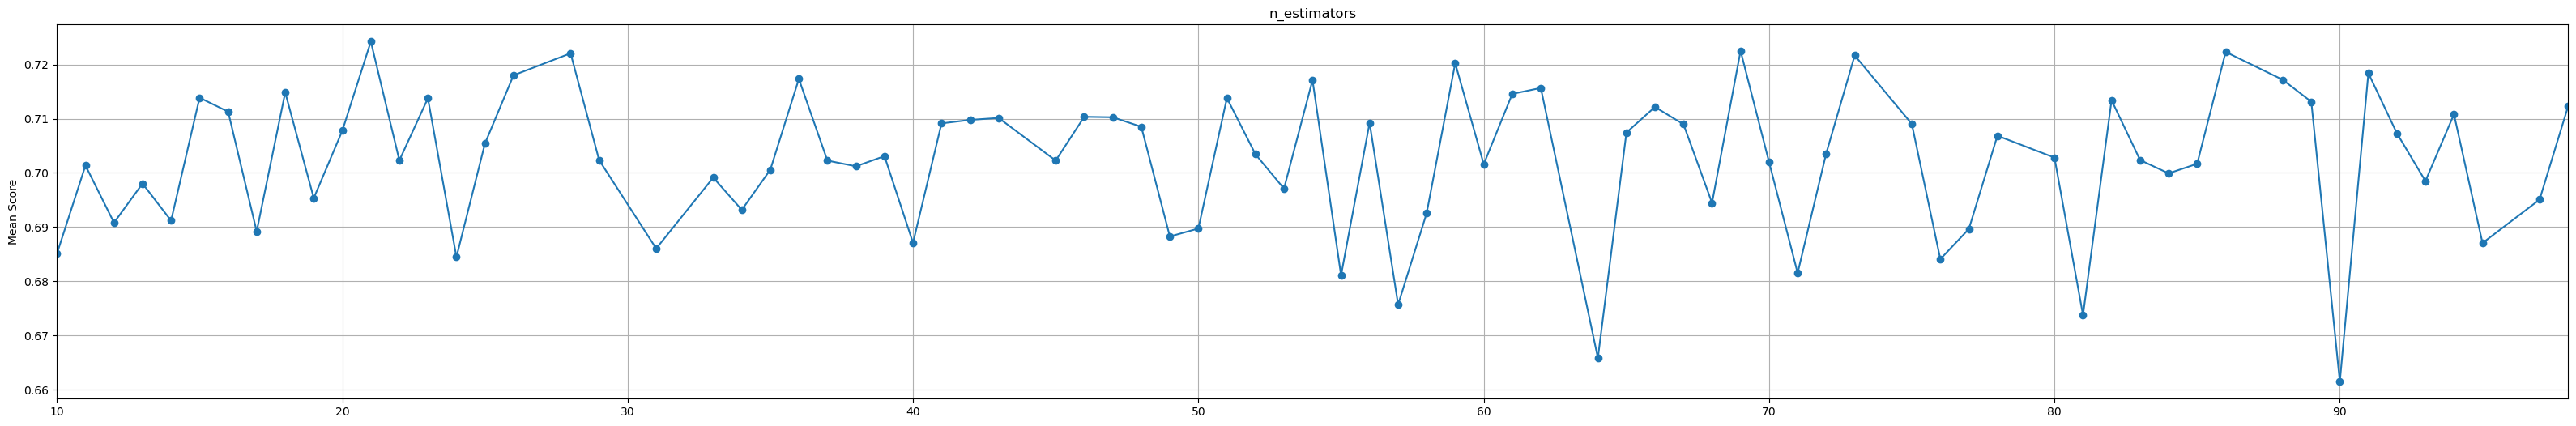

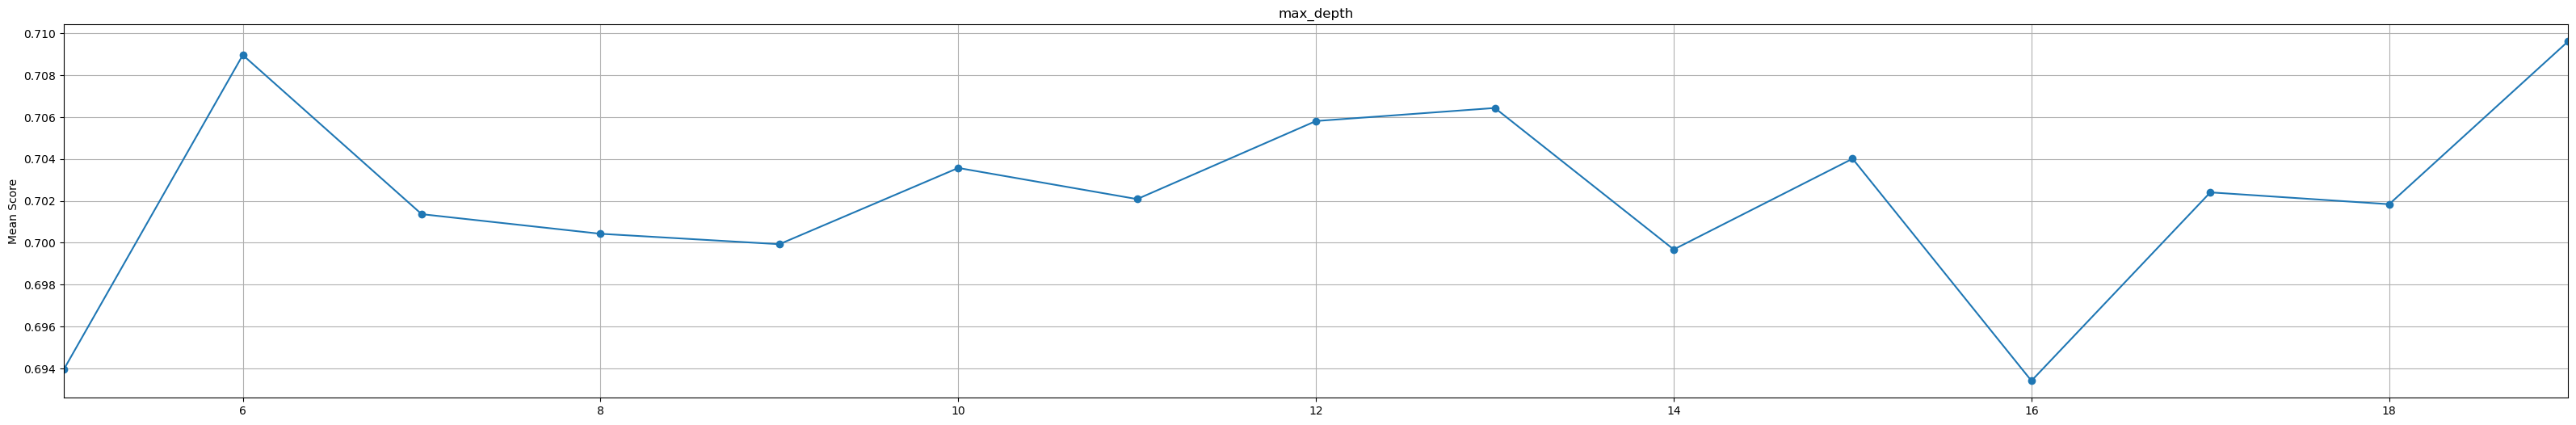

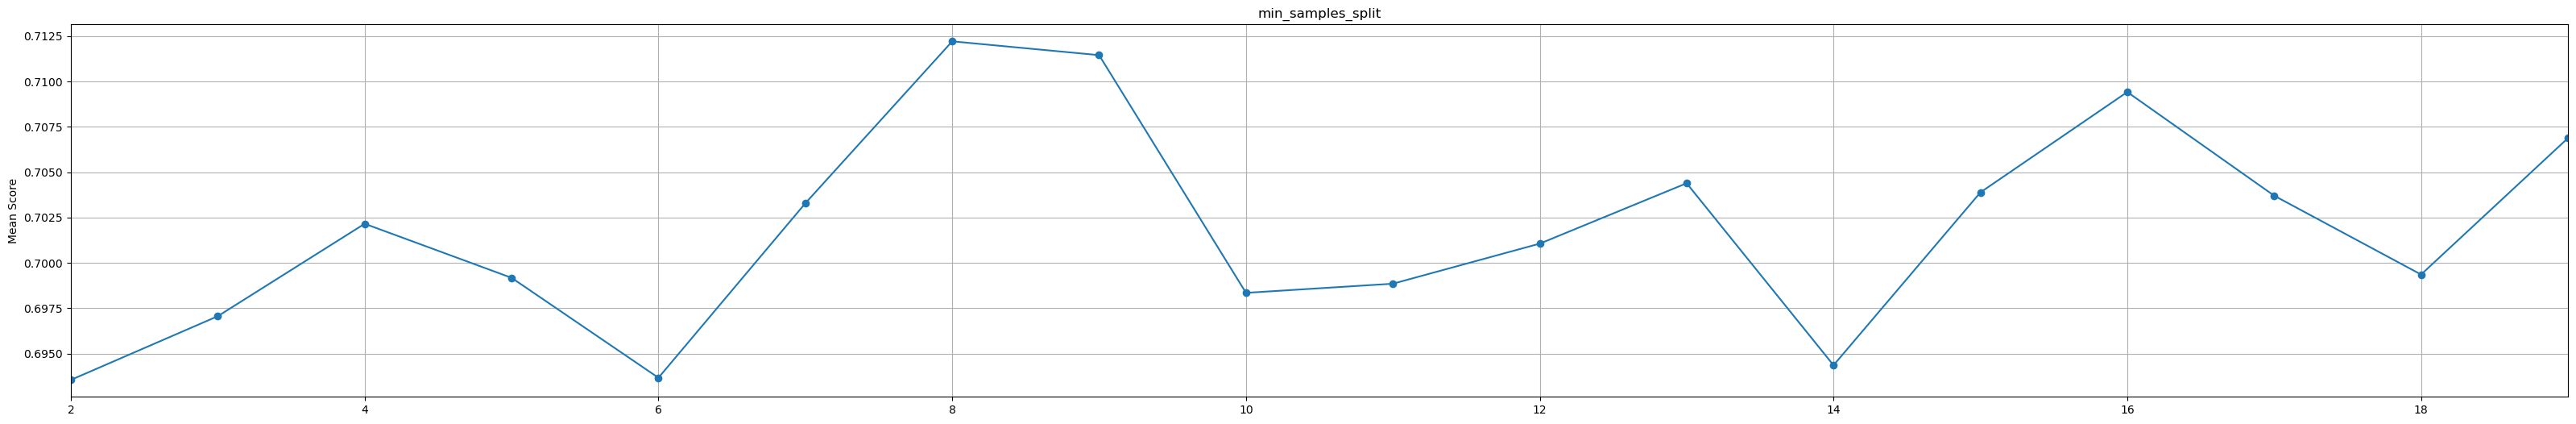

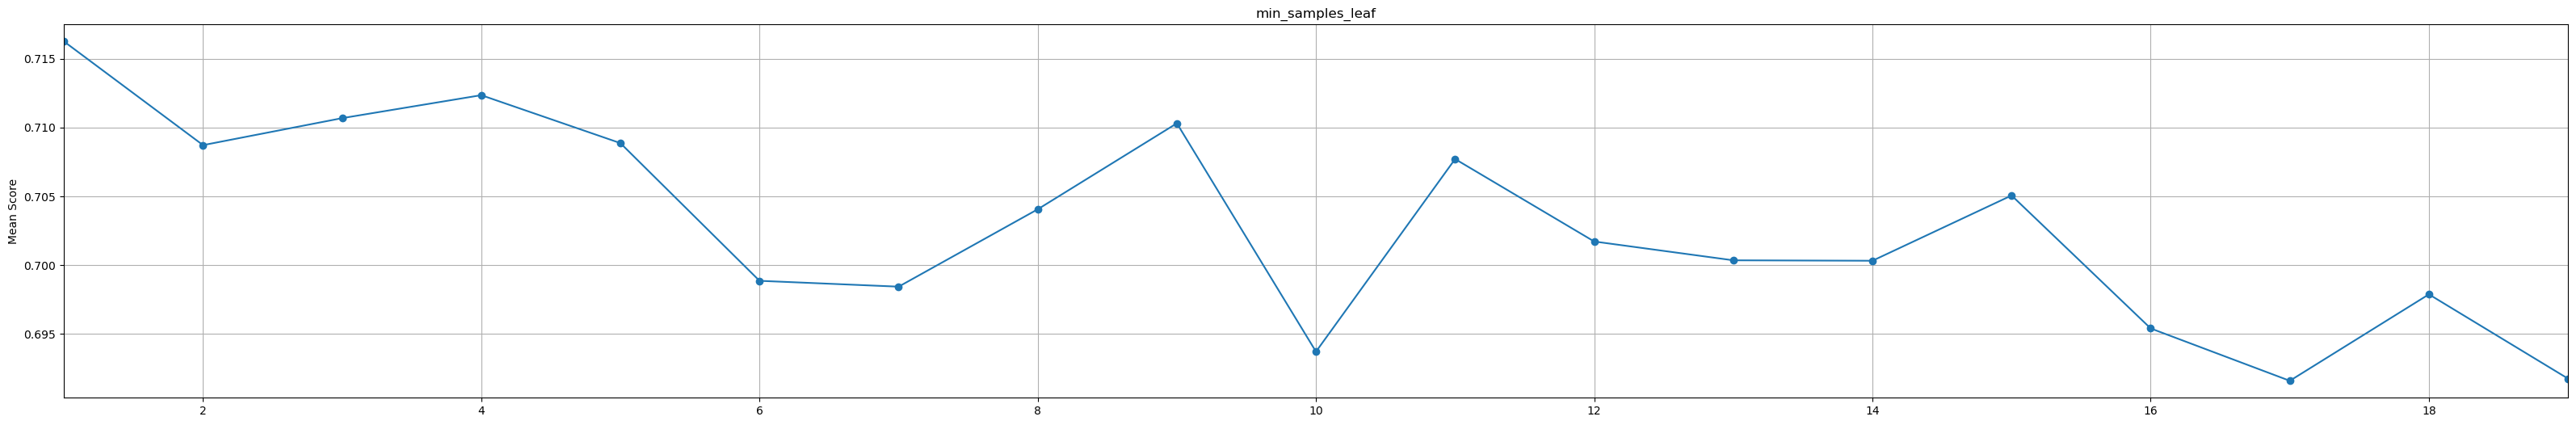

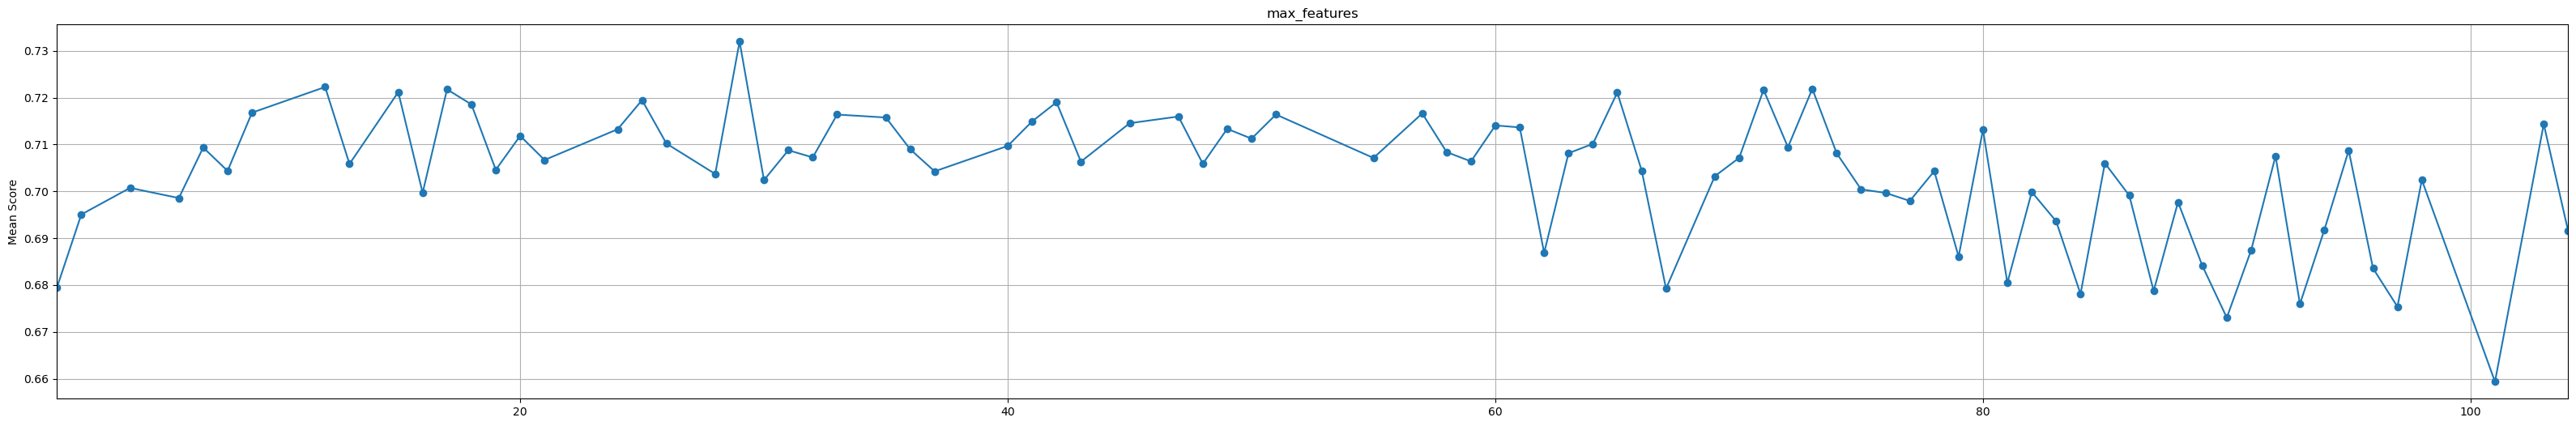

In [ ]:
hyperparameters = [
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
    "max_features",
]

for hyperparam_name in hyperparameters:

    hyperparam_values = rf_rand_search.cv_results_["param_" + hyperparam_name]
    mean_scores = rf_rand_search.cv_results_["mean_test_score"]

    # extract all scores for each hyperparameter value
    hyperparam_tot_scores = dict()
    for value, score in zip(hyperparam_values, mean_scores):
        if value not in hyperparam_tot_scores:
            hyperparam_tot_scores[value] = [score]
        else:
            hyperparam_tot_scores[value].append(score)

    # mean scores for each hyperparameter value
    sorted_hyperparams = sorted(hyperparam_tot_scores.keys())
    averaged_scores = [
        np.nanmean(hyperparam_tot_scores[val]) for val in sorted_hyperparams
    ]

    plt.figure(figsize=(40, 6))
    plt.plot(sorted_hyperparams, averaged_scores, marker="o", linestyle="-")

    plt.xlim([min(sorted_hyperparams), max(sorted_hyperparams)])
    plt.ylabel("Mean Score")
    plt.title(f"{hyperparam_name}")
    plt.grid(True)

    plt.show()


In [ ]:
hyperpar = {
    "n_estimators": [30, 40, 50],
    "criterion": ["log_loss"],
    "max_depth": [10, 11, 12],
    "min_samples_split": [5, 9, 15],
    "min_samples_leaf": [3, 4, 5],
    "max_features": [20, 40, 60],
    "bootstrap": [True],
}

# search all combinations of above values
rf_grid_search = GridSearchCV(
    rf, param_grid=hyperpar, scoring="f1_weighted", cv=5, verbose=1, n_jobs=-1
)

rf_grid_search.fit(expl_train, resp_train)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1), n_jobs=-1,
             param_grid={'bootstrap': [True], 'criterion': ['log_loss'],
                         'max_depth': [10, 11, 12],
                         'max_features': [20, 40, 60],
                         'min_samples_leaf': [3, 4, 5],
                         'min_samples_split': [5, 9, 15],
                         'n_estimators': [30, 40, 50]},
             scoring='f1_weighted', verbose=1)

In [ ]:
rf_grid_search.best_params_, rf_grid_search.best_score_


({'bootstrap': True,
  'criterion': 'log_loss',
  'max_depth': 10,
  'max_features': 40,
  'min_samples_leaf': 5,
  'min_samples_split': 5,
  'n_estimators': 30},
 0.7384591637665474)

In [ ]:
# best model
rf_best = rf_grid_search.best_estimator_


In [ ]:
dump(rf_best, "/home/jovyan/gdata1/projects/jenna_temp/RF_lc_classifier.joblib")


['/home/jovyan/gdata1/projects/jenna_temp/RF_lc_classifier.joblib']

### Feature importance

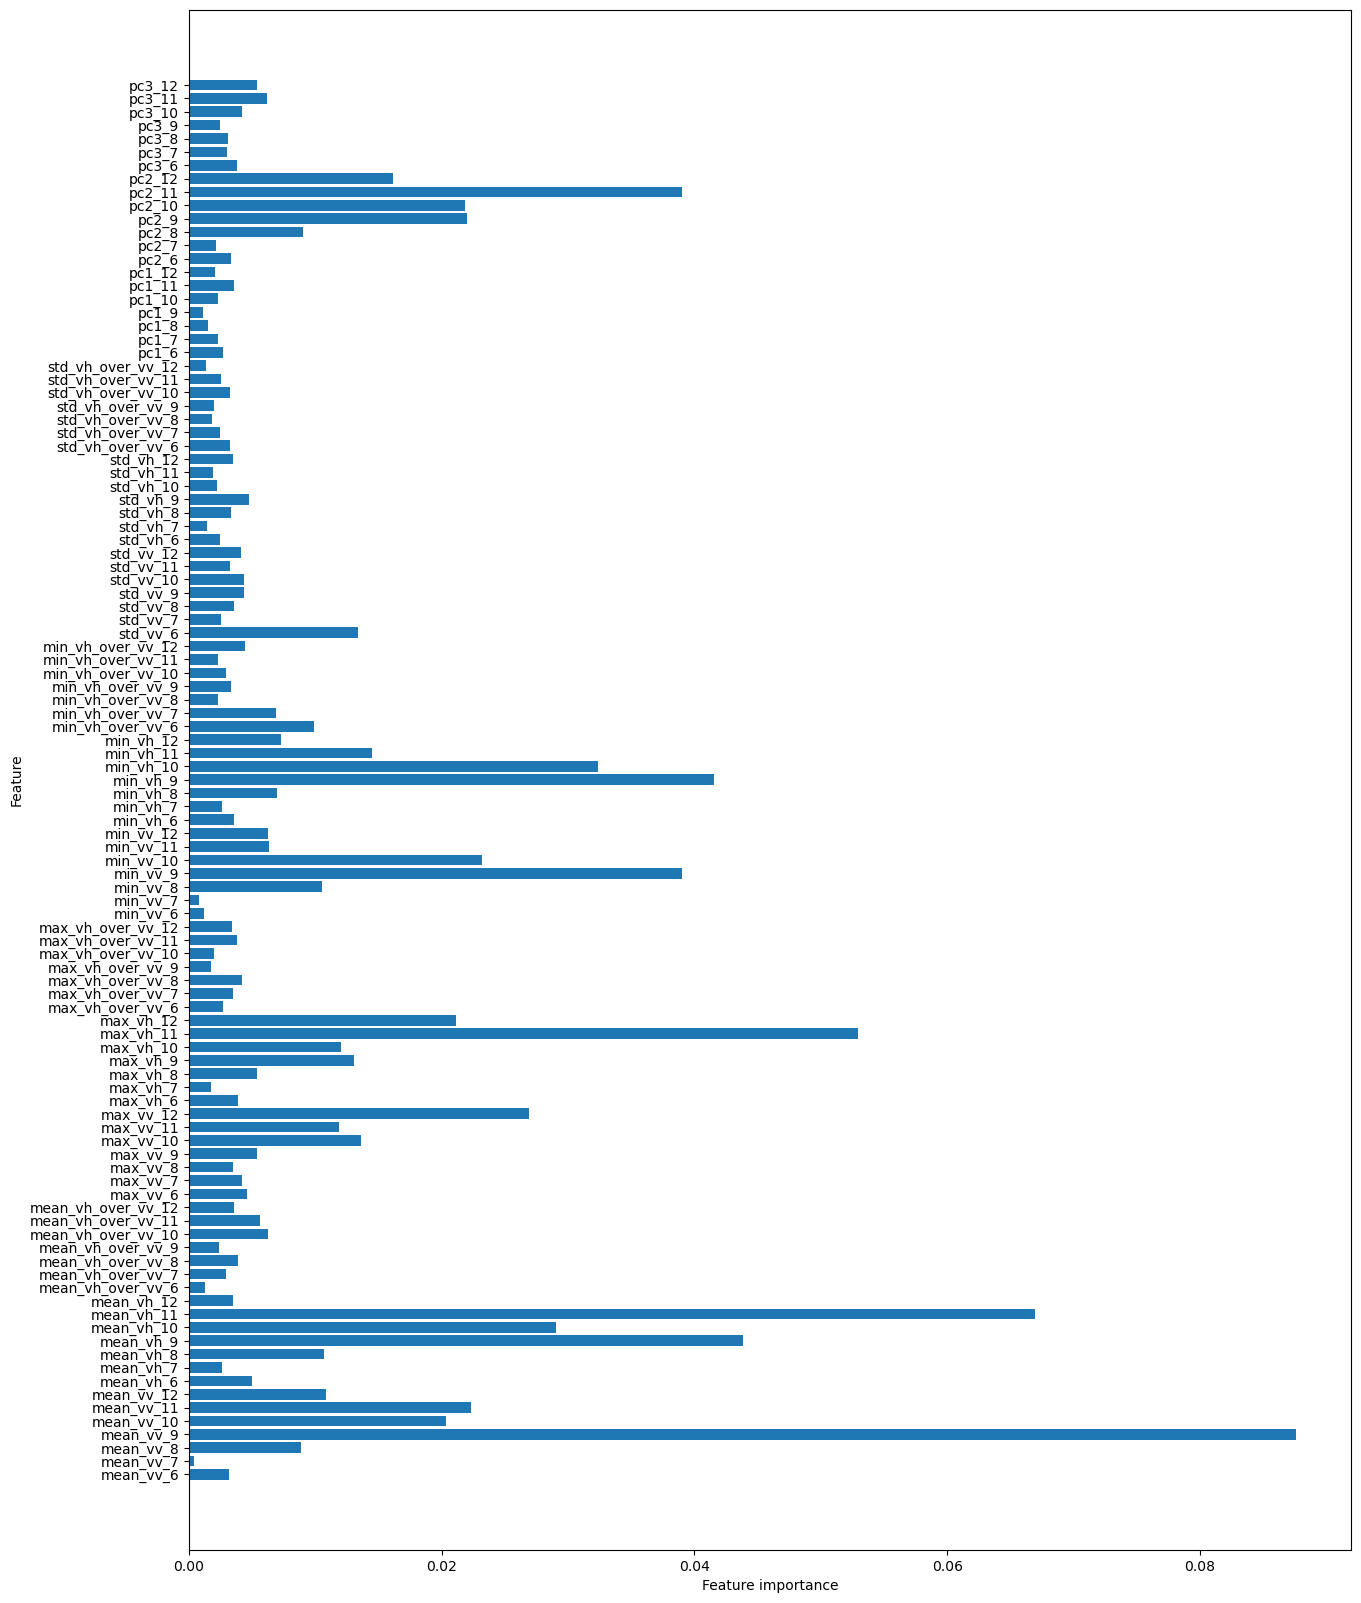

In [ ]:
feat_importances = rf_best.feature_importances_
rf_importance = zip(predictors, feat_importances)

plt.figure(figsize=(15, 20))
plt.barh(predictors, feat_importances)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()


In [ ]:
class_names = {
    111: "Cultivated Terrestrial Vegetation (CTV)",
    112: "(Semi-)Natural Terrestrial Vegetation (NTV)",
    124: "Natural Aquatic Vegetation (NAV)",
    215: "Artificial Surface (AS)",
    216: "Natural Bare Surface (NS)",
    220: "Water",
}


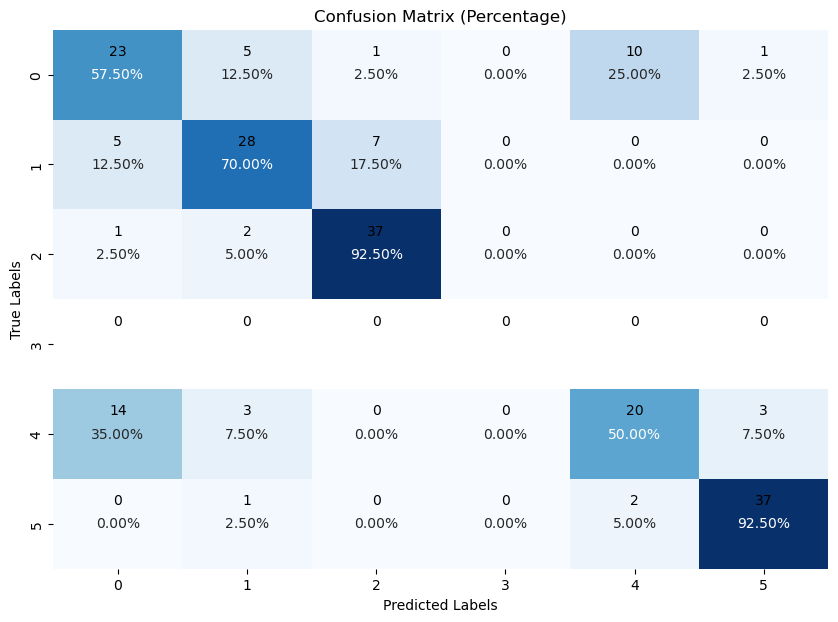

Accuracy: 0.7250
Weighted F1 Score: 0.7206
Weighted Precision: 0.7205
Weighted Recall: 0.7250


In [ ]:
# true labels and predictions
y_true = resp_test.map(inv_class_map)
y_pred = pd.Series(rf_best.predict(expl_test[predictors])).map(inv_class_map)
# y_pred = rf_best.predict(expl_test[predictors])

unique_labels = sorted(class_map.keys())
tick_labels = [class_names[c] for c in unique_labels]

cm = confusion_matrix(y_true, y_pred, labels=unique_labels)

# show percentages (recall)
cm_normalised = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]


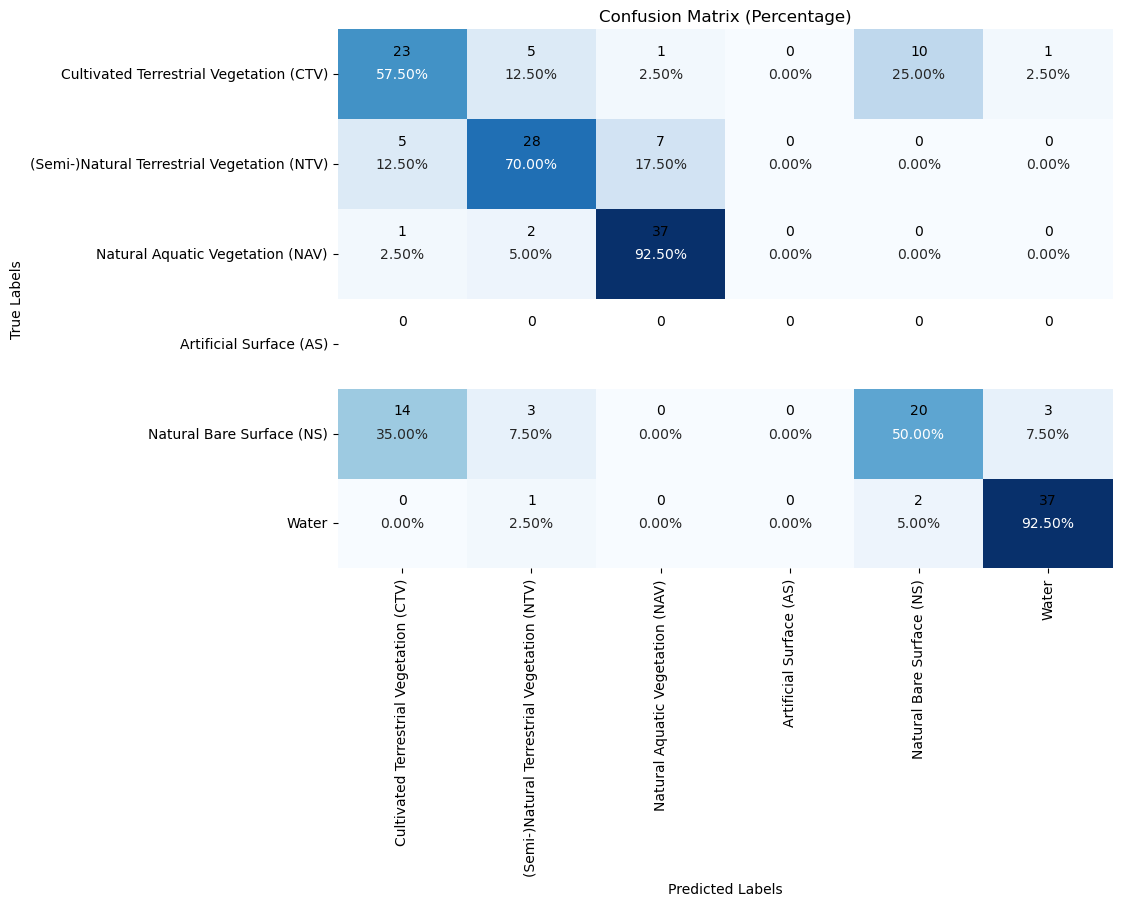

Accuracy: 0.7250
Weighted F1 Score: 0.7206
Weighted Precision: 0.7205
Weighted Recall: 0.7250


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    cm_normalised,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    cbar=False,
    ax=ax,
    xticklabels=tick_labels,
    yticklabels=tick_labels,
)
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_title("Confusion Matrix (Percentage)")

# add counts in the cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j + 0.5, i + 0.5, f"{cm[i, j]}\n", ha="center", va="bottom", color="black"
        )

plt.show()

# metrics
accuracy = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average="weighted")
precision_weighted = precision_score(y_true, y_pred, average="weighted")
recall_weighted = recall_score(y_true, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1_weighted:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")


In [ ]:
# classification summary
report = classification_report(y_true, y_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()

print(report_df)


### Plot on map 

In [ ]:
# 165,155


In [ ]:
# lc_samples = train_points_equal_stratified_random.copy()
# lc_samples["x"] = lc_samples.geometry.x
# lc_samples["y"] = lc_samples.geometry.y


In [ ]:
# def extract_features_at_points(xr_data, x_coords, y_coords):
#     features = []
#     for xi, yi in zip(x_coords, y_coords):
#         vals = []
#         for var in xr_data.data_vars:
#             vals.extend(xr_data[var].sel(x=xi, y=yi, method="nearest").values.flatten())
#         features.append(vals)
#     return np.array(features)


In [ ]:
# lc_samples = train_points_equal_stratified_random.copy()
# lc_samples["x"] = lc_samples.geometry.x
# lc_samples["y"] = lc_samples.geometry.y

# # Flatten the combined_inputs grid for ML
# X_grid_full = sklearn_flatten(combined_inputs)

# # Get the x, y coordinates of the grid
# x_coords = combined_inputs["x"].values
# y_coords = combined_inputs["y"].values


# # Build a mapping from (x, y) to flattened index
# def get_flat_index(xi, yi, x_coords, y_coords):
#     x_idx = np.abs(x_coords - xi).argmin()
#     y_idx = np.abs(y_coords - yi).argmin()
#     return y_idx * len(x_coords) + x_idx


# # Get indices for training points
# indices = [
#     get_flat_index(xi, yi, x_coords, y_coords)
#     for xi, yi in zip(lc_samples["x"], lc_samples["y"])
# ]

# # Extract features for training points from the flattened grid
# X = X_grid_full[indices]
# y = lc_samples["class"].values

# # Train/validation split
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# # Train random forest
# rf = RandomForestClassifier(n_estimators=100, random_state=42)
# rf.fit(X_train, y_train)

# val_score = rf.score(X_val, y_val)
# print(f"Validation accuracy: {val_score:.3f}")

# # Predict over all data arrays
# y_pred_grid = rf.predict(X_grid_full)

# # Unflatten to raster
# raster_pred = sklearn_unflatten(y_pred_grid, combined_inputs)
# raster_pred = xr.DataArray(
#     raster_pred,
#     dims=combined_inputs.dims,
#     coords=combined_inputs.coords,
#     name="rf_class",
# )


# # Plot
# raster_pred.plot.imshow(x="x", y="y", col="time", cmap="tab10", col_wrap=3, size=4)
# plt.show()
